# EDA Summary: San Diego permit approvals (2025)

This is the short version of `basic_eda.ipynb`. Each section has one finding, one chart or table, and a plain-English takeaway.

**The data:** every permit approval the City of San Diego *created* in 2025 (66,317 rows). It was pulled in Oct 2026.

**Our main question:** how long does it take to get a permit, and what makes it take longer?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

ACCENT, MUTED = '#2a78d6', '#9a9890'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c2', 'axes.grid': True, 'grid.color': '#e8e7e3',
    'axes.axisbelow': True, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
log_fmt = mticker.FuncFormatter(lambda x, _: f'{x:g}')

DATE_COLS = ['PROJECT_CREATE_DATE', 'PROJECT_DEEMEDCOMPLETE_DATE', 'APPROVAL_CREATE_DATE',
             'APPROVAL_ISSUE_DATE', 'APPROVAL_CLOSE_DATE']
df = pd.read_csv('data/approvals_created_2025_datasd.csv', low_memory=False, parse_dates=DATE_COLS)

# turnaround = days from application (create) to permit issued
df['turnaround_days'] = (df['APPROVAL_ISSUE_DATE'] - df['APPROVAL_CREATE_DATE']).dt.days

# keep the 12 most common permit types, lump the rest into "Other"
top = df['APPROVAL_TYPE'].value_counts().index[:12]
df['TYPE_GRP'] = df['APPROVAL_TYPE'].where(df['APPROVAL_TYPE'].isin(top), 'Other')

# the two main permit types that need plan review
df['is_plan_review'] = df['APPROVAL_TYPE'].isin(['Building Permit', 'Combination Building Permit'])

# issued / still pending / cancelled
dead = df['APPROVAL_STATUS'].str.contains('Cancel|Withdraw|Expired|Denied|Void', na=False)
df['issue_state'] = np.select([df['APPROVAL_ISSUE_DATE'].notna(), dead],
                              ['issued', 'cancelled'], default='still pending')
df['create_month'] = df['APPROVAL_CREATE_DATE'].dt.to_period('M')

## 1. There are really two kinds of permits

Most permits fall into one of two groups:

- **Over-the-counter permits** like solar panels, traffic control, and simple electrical/plumbing work. They're usually issued **the same day**.
- **Plan-review permits** like building permits and remodels. A city reviewer checks the plans, and these take **about 100 days** on average (median).

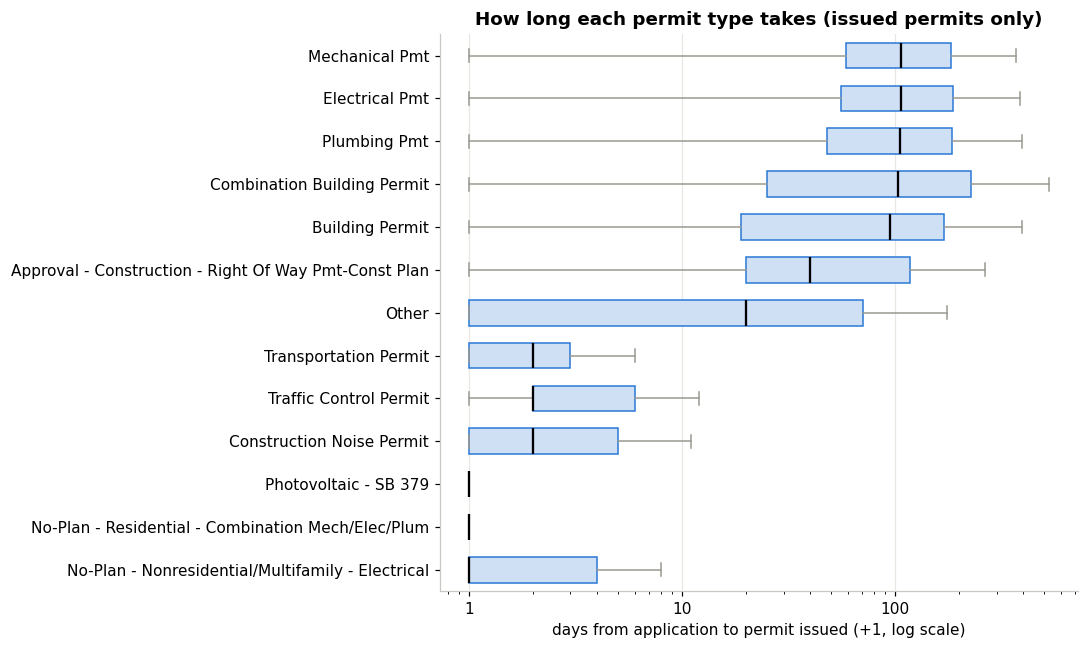

In [2]:
t = df.dropna(subset=['turnaround_days'])
order = t.groupby('TYPE_GRP')['turnaround_days'].median().sort_values().index
data = [t.loc[t['TYPE_GRP'] == g, 'turnaround_days'] + 1 for g in order]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, vert=False, tick_labels=order, showfliers=False, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#cfe0f5', edgecolor=ACCENT),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.set_xscale('log'); ax.xaxis.set_major_formatter(log_fmt)
ax.set_xlabel('days from application to permit issued (+1, log scale)')
ax.set_title('How long each permit type takes (issued permits only)')
ax.grid(axis='y', visible=False)
plt.tight_layout()

In [3]:
# Median = typical case, 90th percentile = slow case
(t.groupby('TYPE_GRP')['turnaround_days']
   .agg(permits='size', typical_days='median', slow_case_days=lambda s: s.quantile(.9))
   .sort_values('typical_days').round(0).astype(int))

,permits,typical_days,slow_case_days
TYPE_GRP,,,
No-Plan - Nonresidential/Multifamily - Electrical,1911,0,31
No-Plan - Residential - Combination Mech/Elec/Plum,9712,0,2
Photovoltaic - SB 379,5965,0,2
Construction Noise Permit,1803,1,6
Traffic Control Permit,9681,1,11
Transportation Permit,2073,1,4
Other,7680,19,205
Approval - Construction - Right Of Way Pmt-Const Plan,2594,39,245
Building Permit,2617,94,285


**Takeaway:** permit type is the biggest driver of wait time. We should probably model the plan-review permits separately. The same-day permits aren't interesting to predict.

*Why medians and not averages?* A few permits take over a year, which pulls the average way up. The median shows the typical case, and the 90th percentile shows the "slow but not extreme" case.

## 2. Warning: a lot of permits aren't done yet

About **1 in 5 permits (21%) don't have an issue date**. Most of these are still waiting, and some were cancelled.

This matters because we can only measure wait time for permits that are *finished*. The slow ones are the most likely to still be waiting, so **our numbers make the city look faster than it really is**. Statisticians call this *censoring*.

In [4]:
df['issue_state'].value_counts(normalize=True).mul(100).round(1).to_frame('% of permits')

,% of permits
issue_state,
issued,79.3
still pending,14.5
cancelled,6.3


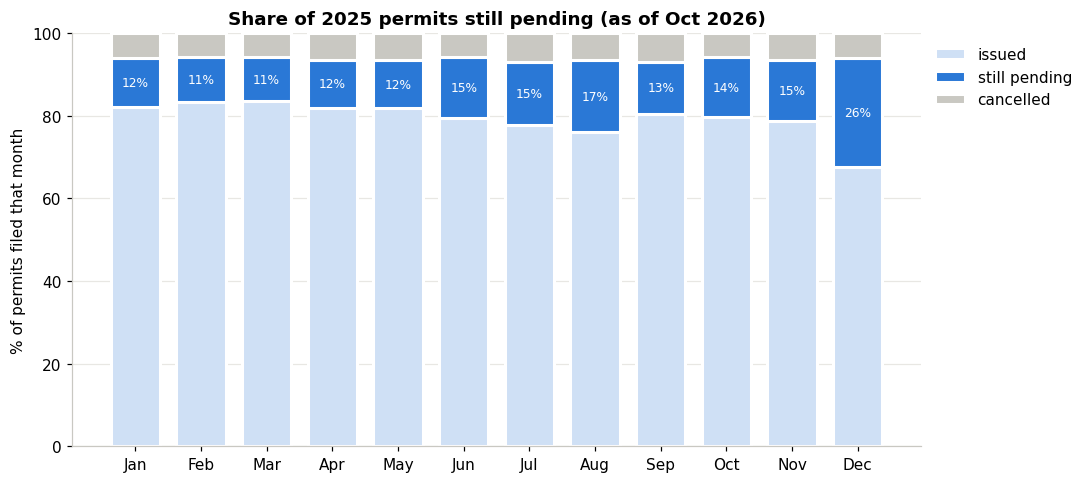

In [5]:
cens = pd.crosstab(df['create_month'], df['issue_state'], normalize='index') * 100
cens = cens[['issued', 'still pending', 'cancelled']]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = cens.index.strftime('%b'); bottom = np.zeros(len(cens))
colors = {'issued': '#cfe0f5', 'still pending': ACCENT, 'cancelled': '#c9c8c2'}
for col in cens.columns:
    ax.bar(x, cens[col], bottom=bottom, color=colors[col], label=col, edgecolor='white', linewidth=2, width=0.75)
    bottom += cens[col].values
for i, v in enumerate(cens['still pending']):
    ax.text(i, cens['issued'].iloc[i] + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white')
ax.set_ylim(0, 100); ax.set_ylabel('% of permits filed that month')
ax.set_title('Share of 2025 permits still pending (as of Oct 2026)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax.grid(axis='x', visible=False)
plt.tight_layout()

**Takeaway:** permits filed later in the year (December especially) are more likely to still be pending. For building permits, **35–45% aren't issued yet**.

**Fix:** pull the 2020–2024 files, where almost everything has finished. Another option is a survival model, which counts unfinished permits as "at least this long".

## 3. Volume is steady month to month

The city gets about **5,000–6,000 permits a month**. November dips, likely because of the holidays. Almost nothing is filed on weekends.

For building permits, the typical wait is **steady at about 90–110 days** all year.

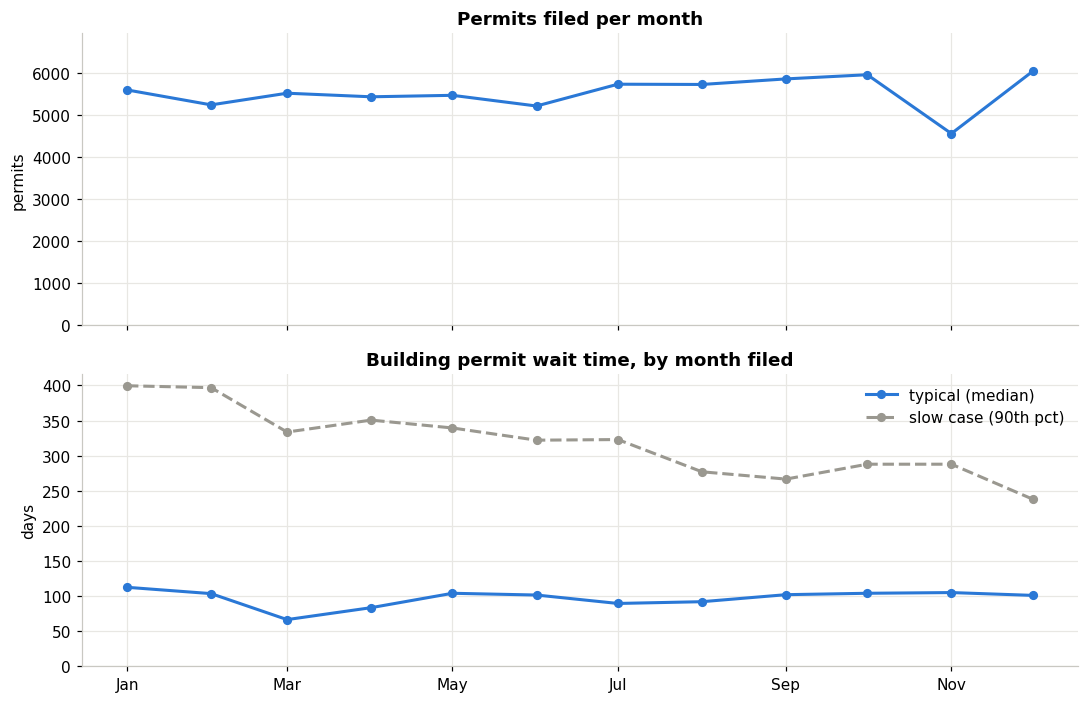

In [6]:
plan = df[df['is_plan_review']].groupby('create_month')['turnaround_days']
monthly = pd.DataFrame({
    'created': df.groupby('create_month').size(),
    'median': plan.median(),
    'p90': plan.quantile(.9),
})

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
x = monthly.index.to_timestamp()
a1.plot(x, monthly['created'], color=ACCENT, lw=2, marker='o', ms=5)
a1.set_ylim(0, monthly['created'].max() * 1.15)
a1.set_title('Permits filed per month'); a1.set_ylabel('permits')

a2.plot(x, monthly['median'], color=ACCENT, lw=2, marker='o', ms=5, label='typical (median)')
a2.plot(x, monthly['p90'], color=MUTED, lw=2, marker='o', ms=5, ls='--', label='slow case (90th pct)')
a2.set_ylim(0, None); a2.set_ylabel('days')
a2.set_title('Building permit wait time, by month filed')
a2.legend(frameon=False)
a2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
plt.tight_layout()

**Takeaway:** the grey "slow case" line drops from about 400 to about 240 days over the year. **That's not the city getting faster.** It's the censoring problem from section 2. Later permits haven't had time to show their slow cases yet.

## 4. Bigger projects take longer

**Valuation** is the estimated dollar cost of the project. More expensive projects take longer to get approved.

We measure this with the *Spearman correlation*, which runs from -1 to 1 (0 = no relationship). Valuation scores **about 0.53**, a fairly strong link. It still holds when we look only at building permits, so it's not just a side effect of permit type.

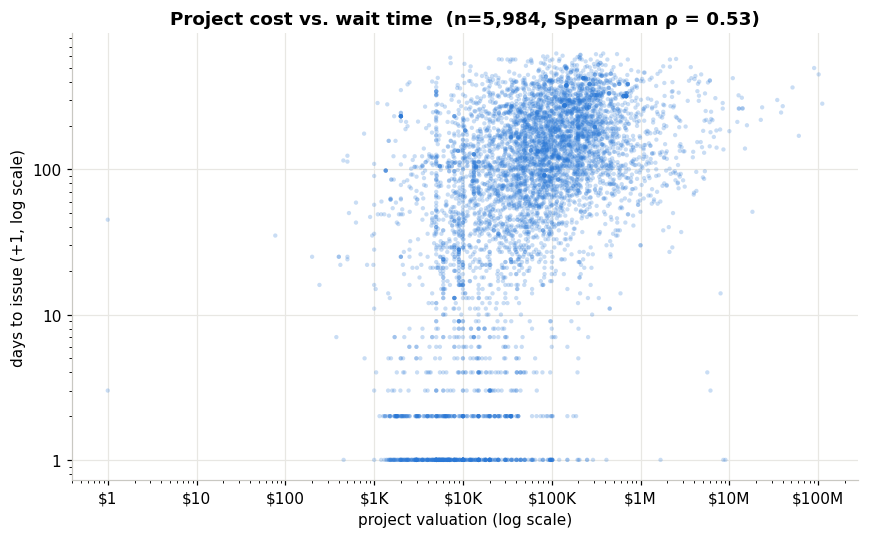

In [7]:
v = df[(df['APPROVAL_VALUATION'] > 0) & df['turnaround_days'].notna()]
rho = spearmanr(v['APPROVAL_VALUATION'], v['turnaround_days'])[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(v['APPROVAL_VALUATION'], v['turnaround_days'] + 1, s=8, alpha=0.25, color=ACCENT, edgecolors='none')
ax.set_xscale('log'); ax.set_yscale('log')
def money(x, _):
    for div, suf in [(1e9, 'B'), (1e6, 'M'), (1e3, 'K')]:
        if x >= div: return f'${x/div:g}{suf}'
    return f'${x:g}'
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.yaxis.set_major_formatter(log_fmt)
ax.set_xlabel('project valuation (log scale)'); ax.set_ylabel('days to issue (+1, log scale)')
ax.set_title(f'Project cost vs. wait time  (n={len(v):,}, Spearman ρ = {rho:.2f})')
plt.tight_layout()

In [8]:
# Other "size" measures are mostly empty, but here's what we have
rows = []
for c, label in [('APPROVAL_VALUATION', 'Valuation ($)'), ('APPROVAL_ADU_TOTAL', '# of ADUs'),
                 ('APPROVAL_STORIES', '# of stories'), ('APPROVAL_FLOOR_AREA', 'Floor area')]:
    sub = df[(df[c] > 0) & df['turnaround_days'].notna()]
    rows.append({'measure': label, 'permits with data': len(sub),
                 'correlation with wait': round(spearmanr(sub[c], sub['turnaround_days'])[0], 2)})
pd.DataFrame(rows).set_index('measure')

,permits with data,correlation with wait
measure,,
Valuation ($),5984,0.53
# of ADUs,1043,0.29
# of stories,539,0.20
Floor area,73,0.17


**Takeaway:** valuation is a useful predictor. ADU count and stories have weaker links. Floor area is too sparse to use (only 73 permits).

## 5. Experienced applicants seem to get permits faster

A small number of contractors file a large share of permits. The **top 10 file about 1 in 4** permits, and SDG&E alone files about 10%.

To check whether experience matters, we compare **only building permits**, so we're not just picking up permit type.

In [9]:
holder = df['APPROVAL_PERMIT_HOLDER'].str.upper().str.strip()
volume = holder.map(holder.value_counts())
df['applicant_experience'] = pd.cut(volume, [0, 1, 5, 20, np.inf],
                                    labels=['1st-time filer', '2-5 permits', '6-20 permits', '21+ permits'])

(df[df['APPROVAL_TYPE'] == 'Building Permit']
   .groupby('applicant_experience', observed=True)['turnaround_days']
   .agg(permits='size', typical_days='median').round(0))

,permits,typical_days
applicant_experience,,
1st-time filer,241,99.0
2-5 permits,830,118.0
6-20 permits,773,98.0
21+ permits,994,20.0


**Takeaway:** for building permits, frequent filers (21+) get their permit in **about 20 days**, compared with **about 100 days** for everyone else. This could mean experienced applicants submit cleaner plans and need fewer corrections. It's a promising feature for our model.

*Caveat:* this is a first look. Frequent filers might also file simpler projects, so we'll need to control for project size.

## 6. Data quality: what's usable

| | |
|---|---|
| **Good** | Dates are clean (no impossible or placeholder dates). Each permit ID is unique. Only 3% are missing a location. |
| **Missing by design** | 58% of permits have no "project" attached (the simple same-day permits), so project-level columns are blank for them. |
| **Mostly empty** | Floor area, stories, and dwelling-unit change are 98–100% blank. The ~25 affordable-housing columns are 86% blank, so we collapse them into a single "is housing" flag. |
| **Safe to drop** | Trust account number, drawing number, street address (we have lat/long), and expiration date. |

## Next steps

1. **Pull 2020–2024 data** so we can measure wait times without the censoring problem.
2. **Focus the model on plan-review permits.** The same-day ones aren't worth predicting.
3. **Candidate predictors:** permit type, valuation, review track (Standard / Express / Expedite), applicant experience, housing/ADU flag, and keywords from the project description (ADU, retaining wall, and EV charger projects are among the slowest).